In [27]:
# Importar las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # libreria para graficar el árbol de decisión
#Herramientas de Scikit-Learn para Machine Learning
from sklearn.model_selection import train_test_split # para divir en Train/Test
from sklearn.tree import DecisionTreeClassifier , plot_tree #El modelo y graficador
from sklearn.metrics import accuracy_score, classification_report #métricas de evaluación

#Cargamos el archivo desde excel
from google.colab import files
import io

uploaded=files.upload()
nombre_archivo = list(uploaded.keys())[0]
print(f"Leyendo archivo: {nombre_archivo}")

#Cargamos las hojas del Excel que vamos a utilizar
df_clientes_str = pd.read_excel (io.BytesIO(uploaded[nombre_archivo]), sheet_name = 'clientes')
df_nuevos_str = pd.read_excel (io.BytesIO(uploaded[nombre_archivo]), sheet_name = 'clientes_nuevos')
print ("Archivo cargado con éxito.")

Saving clientes_streamtico.xlsx to clientes_streamtico (2).xlsx
Leyendo archivo: clientes_streamtico (2).xlsx
Archivo cargado con éxito.


In [28]:
# Explorar el archivo excel para limpiar los datos

print("***Primeros cinco registros de la tabla: ***")
print (df_clientes_str.head() , "\n")

print("*** Tipo de Datos: ***")
print (df_clientes_str.info(), "\n")

print ("*** Valores Vacios (Nulos): ***")
print (df_clientes_str.isnull().sum(), "\n")

print ("*** Registros duplicados: ***")
print (df_clientes_str.duplicated().sum(), "\n")

print ("*** Mínimos y Máximos numéricos: ***")
print (df_clientes_str.describe(), "\n")

print ("*** Valores únicos / Columnas Texto: ***")
print ("Valores únicos en columna plan:", df_clientes_str['plan'].unique())
print ("Valores únicos en columna cancelo: ", df_clientes_str['cancelo'].unique())

***Primeros cinco registros de la tabla: ***
  id_cliente  edad  meses_activo  quejas     plan gasto_mensual  \
0    CL-1001    41          52.0       2   Básico          5750   
1    CL-1002    35          11.0       1   Básico          4500   
2    CL-1003    30           2.0       0  Basico           4500   
3    CL-1004    44          39.0       2   Básico          5500   
4    CL-1005    29          22.0       2  Premium         11150   

            encuesta_salida cancelo  
0                       NaN      No  
1  Mala atención al cliente      Sí  
2                       NaN      No  
3                       NaN      No  
4                       NaN      No   

*** Tipo de Datos: ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_cliente       306 non-null    object 
 1   edad             306 non-null    int64  
 2   meses_

**Número de error: 1**
Columna afectada: id_cliente
Cómo lo detectaste: con  df_clientes.duplicated().sum() detectó 6 registros repetidos
Cómo lo corregiste: Se eliminaron con df.drop_duplicates().

**Número de error: 2**
Columna afectada: edad, mostró un valor mínimo de -4
Cómo lo detectaste: con df_clientes.describe()
Cómo lo corregiste: Se reemplazaron los valores menores a 18 por la mediana de edad.

**Número de error: 3**
Columna afectada: edad, mostró un valor mínimo de -4
Cómo lo detectaste: con df_clientes.describe() mostró un valor máximo fuera de rango: 250
Cómo lo corregiste: Se reemplazaron los valores mayores a 100 por la mediana de edad.

**Número de error: 4**
Columna afectada: meses_activo,
Cómo lo detectaste: df_clientes.info() y .isnull().sum(). se detectaron 7 valores vacíos (NaN)
Cómo lo corregiste: Se rellenaron las celdas vacías con la mediana de la columna

**Número de error: 5**
Columna afectada: meses_activo,
Cómo lo detectaste: df_clientes.describe() mostró un máximo de 999
Cómo lo corregiste: Se reemplazaron los valores mayores a 60 por la mediana de la columna.

**Número de error: 6**
Columna afectada: quejas
Cómo lo detectaste: df_clientes.describe() mostró un mínimo de -3
Cómo lo corregiste: Se reemplazaron los valores negativos a 0 (ausencia de quejas).

**Número de error: 7**
Columna afectada: gasto_mensual
Cómo lo detectaste: df_clientes.info() detectó tipo object (texto)
Cómo lo corregiste: Se quitó el símbolo ₡ y las comas, se cambió la columna a numérico.

**Número de error: 8**
Columna afectada: plan
Cómo lo detectaste:unique() detectó mezcla de mayúsculas, espacios y tildes.
Cómo lo corregiste: Se limpio los espacios y se estandarizó el texto a Básico, Estándar y Premium.

**Número de error: 9**
Columna afectada: cancelo
Cómo lo detectaste:df_clientes.isnull().sum() se detectó 4 valores vacíos (NaN).
Cómo lo corregiste: Se rellenaron con 'No'

**Número de error: 10**
Columna afectada: cancelo
Cómo lo detectaste:df_clientes['cancelo'].unique() se detectaron variaciones como 'si', 'NO', o 'SI'.
Cómo lo corregiste: Se homogeneizaron todas a 'Sí' o 'No'.

In [29]:
#limpeza de la tabla

#Eliminar filas duplicadas
df_clientes_str.drop_duplicates(inplace=True)

#Corregir formato numérico en "gasto_mensual" (quitar texto)
df_clientes_str['gasto_mensual'] = df_clientes_str ['gasto_mensual'].astype(str).replace ('₡', '', regex=False)
df_clientes_str['gasto_mensual'] = df_clientes_str['gasto_mensual'].str.replace(',', '', regex=False).str.strip()
df_clientes_str['gasto_mensual'] = pd.to_numeric(df_clientes_str['gasto_mensual'], errors='coerce')


#Corregir valores númericos fuera de rango (edad, meses, gastos)
#Calcular las medianas
mediana_edad = df_clientes_str.loc[(df_clientes_str ['edad'] >=18) & (df_clientes_str ['edad'] <=100), 'edad'].median()
mediana_meses = df_clientes_str.loc [(df_clientes_str['meses_activo'] >=1) & (df_clientes_str['meses_activo'] <=60), 'meses_activo'].median()
mediana_gastos = df_clientes_str['gasto_mensual'].median()

#Aplicar correciones en los rangos (edad, meses_activo, quejas)
df_clientes_str.loc[(df_clientes_str['edad'] < 18) | (df_clientes_str['edad'] > 100), 'edad'] = mediana_edad
df_clientes_str['edad'] = df_clientes_str['edad'].fillna(mediana_edad)

df_clientes_str.loc[(df_clientes_str['meses_activo'] < 1) | (df_clientes_str['meses_activo'] > 60), 'meses_activo'] = mediana_meses
df_clientes_str['meses_activo'] = df_clientes_str['meses_activo'].fillna(mediana_meses)

df_clientes_str.loc[df_clientes_str['quejas'] <0, 'quejas'] = 0
df_clientes_str['quejas'] = df_clientes_str['quejas'].fillna(0)

df_clientes_str['gasto_mensual'] = df_clientes_str['gasto_mensual'].fillna(mediana_gastos)

#Convertir columnas a tipos de dato enteros
df_clientes_str['edad'] = df_clientes_str['edad'].astype(int)
df_clientes_str['meses_activo'] = df_clientes_str['meses_activo'].astype(int)
df_clientes_str['quejas'] = df_clientes_str['quejas'].astype(int)

#Convertir columnas a tipos de datos enteros
df_clientes_str['edad'] = df_clientes_str ['edad'].astype(int)
df_clientes_str['meses_activo'] = df_clientes_str['meses_activo'].astype(int)
df_clientes_str['quejas'] = df_clientes_str['quejas'].astype(int)

#Corregir formato de texto en "plan" /cambia el formato a uno solo reemplazandolos por los valores estandar
df_clientes_str['plan'] = df_clientes_str['plan'].astype(str).str.strip().str.upper()
df_clientes_str['plan'] = df_clientes_str['plan'].replace({
'BÁSICO': 'Básico', 'BASICO': 'Básico',
    'ESTÁNDAR': 'Estándar', 'ESTANDAR': 'Estándar',
    'PREMIUM': 'Premium'
})

#Reemplazar nulos en la variable objetivo "cancelo" y estandarizar el formato
df_clientes_str['cancelo'] = df_clientes_str['cancelo'].fillna('No')
df_clientes_str['cancelo'] = df_clientes_str['cancelo'].astype(str).str.strip().str.upper()
df_clientes_str['cancelo'] = df_clientes_str['cancelo'].replace({'SI': 'Sí', 'NO': 'No'})

#Reemplazar los nulos en la columna "encuesta_salida"
df_clientes_str['encuesta_salida'] = df_clientes_str['encuesta_salida'].fillna('Sin comentarios')

# Verificar que se haya hecho la limpieza de datos
print ("*** Limpieza de la tabla completada ***")
print (f"Cantidad total de filas que quedan: {len(df_clientes_str)}")
print ("\nConteo de valores vacíos por columna (Debe quedar en 0):")
print (df_clientes_str.isnull().sum())





*** Limpieza de la tabla completada ***
Cantidad total de filas que quedan: 300

Conteo de valores vacíos por columna (Debe quedar en 0):
id_cliente         0
edad               0
meses_activo       0
quejas             0
plan               0
gasto_mensual      0
encuesta_salida    0
cancelo            0
dtype: int64


Seleccion de Variables:

* **Variables Incluidas en X (Pistas):** se seleccionarán `edad`, `meses_activo`, `quejas`, `gasto_mensual` y el `plan` (se convertirá a valores numéricos). ya que aportan patrones relacionados con la fidelidad del cliente.
* **Variable Objetivo Y (Respuesta):** se seleccionarán `cancelo` porque es la variable que el modelo debe aprender a predecir (si un cliente abandonará o no el servicio).
* **Variables Excluidas:** `id_cliente` porque no aporta información de comportamiento, y `encuesta_salida` porque se recolecta *después* de que el cliente ya canceló.

In [30]:
#Definición de variables Independientes (X) y Dependiente (Y)

#revisamos que la columna "cancelo" esté limpia (sin espacios)
#transformamos la variable objetico "cancelo" a formato numérico (Sí =1 , No = 0)
df_clientes_str['cancelo'] = df_clientes_str['cancelo'].astype (str).str.strip().str.capitalize()
df_clientes_str['cancelo'] = df_clientes_str['cancelo'].replace({'Si': 'Sí', 'No': 'No', 'Nan': 'No'})
y= df_clientes_str['cancelo'].map({'Sí': 1, 'No': 0})
y= y.fillna(0).astype(int) #por si queda algun nulo oculto, forzamos a 0 (no cancelo)

#seleccionamos las columnas de comportamiento del cliente
columnas_x = df_clientes_str[['edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual' ]]

#transformamos la columna de texto "plan" a formato numérico (tipo "plan_basico", "plan_estándar" con 0 y 1)
X = pd.get_dummies(columnas_x, columns = ['plan'], drop_first = False)

#Convertimos los valores booleanos resultantes (True/False) a números enteros (1/0)
#usamos un condicional por si cambian los nombres detectados en la tabla
columnas_plan = [ c for c in X.columns if 'plan_' in c]
for col in columnas_plan:
  X[col] = X[col].astype(int)

print("*** Primeras filas de las variables (X) ***")
display(X.head())
print("\n *** Distribución de la variable (y) ***")
print (y.value_counts())


*** Primeras filas de las variables (X) ***


,edad,meses_activo,quejas,gasto_mensual,plan_Básico,plan_Estándar,plan_Premium
0,41,52,2,5750.0,1,0,0
1,35,11,1,4500.0,1,0,0
2,30,2,0,4500.0,1,0,0
3,44,39,2,5500.0,1,0,0
4,29,22,2,11150.0,0,0,1



 *** Distribución de la variable (y) ***
cancelo
0    230
1     70
Name: count, dtype: int64


In [31]:
#Dividir entrenamiento (80%) y prueba (20%)

#Dividimos los datos con random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
) # mantiene la misma proporción de cancelados en ambas partes

print (f"Dimensiones de X para entrenamiento (80%): {X_train.shape}")
print (f"Dimensiones de X para prueba (20%): {X_test.shape}")
print (f"Muestras de entrenamiento: {y_train.shape[0]}) | Muestras de prueba: {y_test.shape[0]}")




Dimensiones de X para entrenamiento (80%): (240, 7)
Dimensiones de X para prueba (20%): (60, 7)
Muestras de entrenamiento: 240) | Muestras de prueba: 60


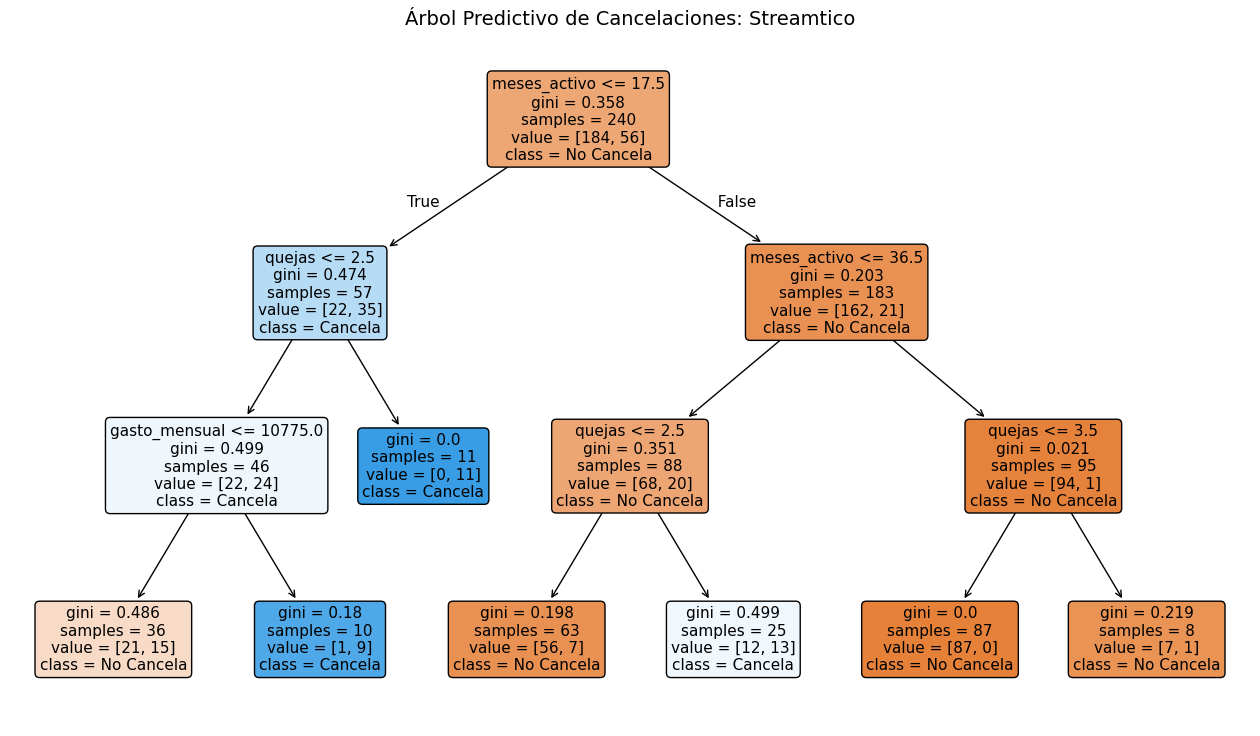

In [32]:
# Entrenar y graficar el árbol de decisión

#Modelo con los parámetros max_depth=3 y random_state=42, dibujado con plot_tree
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)

#Entrenamos el modelo usando los datos de aprendizaje
modelo_arbol.fit(X_train, y_train)

#Graficamos el árbol de decisión
plt.figure(figsize=(16, 9))
plot_tree(modelo_arbol, feature_names=X.columns, class_names=['No Cancela', 'Cancela'], filled=True, rounded=True, fontsize=11)
plt.title ("Árbol Predictivo de Cancelaciones: Streamtico", fontsize=14 )
plt.show()





In [33]:
#Evaluación del modelo y la métricas

#Realizamos las predicciones con el conjunto de datos de prueba
y_pred = modelo_arbol.predict(X_test)

#Calculamos la precisión del modelo (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo con los datos de prueba: {accuracy:.2%}\n")
print ("*** Reporte Detallado ***")
print (classification_report(y_test, y_pred, target_names=['No Cancela', 'Cancela']))


Precisión del modelo con los datos de prueba: 81.67%

*** Reporte Detallado ***
              precision    recall  f1-score   support

  No Cancela       0.87      0.89      0.88        46
     Cancela       0.62      0.57      0.59        14

    accuracy                           0.82        60
   macro avg       0.74      0.73      0.74        60
weighted avg       0.81      0.82      0.81        60



In [40]:
#Para predicción de clientes nuevos / Si cancelan o No

#Seleccionamos las variables predictoras de la hoja de excel clientes
X_nuevos_str = df_nuevos_str[['edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual']]

#Transformamos la columna "plan" en los nuevos datos a numérico
X_nuevos = pd.get_dummies(X_nuevos_str, columns=['plan'], drop_first=False)

#transformaos los valores booleanos a enteros (0/1)
for col in [ c for c in X_nuevos.columns if 'plan_' in c]:
  X_nuevos[col] = X_nuevos[col].astype(int)

#Ordenamos las columnas para que tengan el mismo orden que X_train
#Si falta alguna categoria de "plan", se rellenará automaticamente con ceros
X_nuevos = X_nuevos.reindex(columns=X.columns, fill_value=0)

#Realizamos la predicción con el modelo entrenado
predicciones_nuevas = modelo_arbol.predict(X_nuevos)

#Transformamos el resultado numérico (0 y 1) a texto para el reporte
df_nuevos_str['Prediccion_Cancelo'] = pd.Series(predicciones_nuevas).map({1: 'Sí', 0: 'No'})

print ("*** Resultados de predicción para Clientes Nuevos: ***")
display (df_nuevos_str[['id_cliente', 'edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual', 'Prediccion_Cancelo']])

*** Resultados de predicción para Clientes Nuevos: ***


,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,Prediccion_Cancelo
0,NV-01,24,2,4,Básico,4750,Sí
1,NV-02,45,48,0,Premium,10900,No
2,NV-03,31,6,2,Estándar,7400,No
3,NV-04,58,30,1,Estándar,7900,No
4,NV-05,37,12,5,Básico,5250,Sí


**Conclusión:**

**Perfil de cliente propenso a cancelar:** Los clientes que tienden a cancelar su suscripción son los que acumulan un alto número de quejas y los usuarios que se encuentran en sus primeros meses de servicio (meses_activo bajos),insatisfechos con la atención al cliente.
**Recomendaciones para StreamTico:**
Implementar un sistema de alertas para que usuarios con más de una queja registrada reciba un seguimiento antes de que decida abandonar el servicio.
Diseñar estrategias de fidelización durante los primeros 3 meses del cliente, ofrecer asistencia guiada y encuestas de satisfacción para mitigar el abandono.